In [1]:
import numpy as np
from gymnasium import spaces
import gymnasium as gym
import os, sys
import pandas as pd
import math
import tensorflow as tf


class DigitalTwin():
    """

    """
    def __init__(self, path_cavity_data, linac="North", implementation="np"):
        """

        :param path_cavity_data:
        """

        self.name = linac
        self.implementation = implementation

        data = pd.read_pickle(path_cavity_data)
        regex = r'*'
        if linac.lower() == 'north' or linac.lower() == "n":
            regex = r'1L*'
            self.energyConstraint = 1050
            self.energyMargin = 2
        elif linac.lower() == "south" or linac.lower() == "s":
            regex = r'2L*'
            self.energyConstraint = 1050
            self.energyMargin = 2
        elif linac.lower() == "1l06_test1":
            regex = r'1L06-1'
            self.energyConstraint = 2.5 #7.85
            self.energyMargin = 0.1
        elif linac.lower() == "1l06_test2":
            regex = r'1L06-?[1-2]'
            self.energyConstraint = 7.85 #7.85
            self.energyMargin = 0.1
        elif linac.lower() == "1l06_test4":
            regex = r'1L06-?[1-4]'
            self.energyConstraint = 15.95 #7.85
            self.energyMargin = 0.2
        elif linac.lower() == "1l06_test8":
            regex = r'1L06-?[1-8]'
            self.energyConstraint = 31.8 #7.85
            self.energyMargin = 0.2
#         elif linac.lower() == "1l10_test1":
#             regex = r'1L10-1'
        elif linac.lower() == "1l10_test2":
            regex = r'1L10-?[1-2]'
            self.energyConstraint = 4.5 #7.85
            self.energyMargin = 0.1
        elif linac.lower() == "1l10_test4":
            regex = r'1L10-?[1-4]'
            self.energyConstraint = 9.1 #7.85
            self.energyMargin = 0.2
        elif linac.lower() == "1l10_test8":
            regex = r'1L10-?[1-8]'
            self.energyConstraint = 20.08 #17.3 #7.85
            self.energyMargin = 0.4
        else: #Injector
            regex = r'0L*'
            self.energyConstraint = 126.5
            self.energyMargin = 0.22


        linac_indices = data["cavity_id"].str.match(regex).astype(bool)
        data = data[linac_indices]

        self.cavity_ids = np.array(data["cavity_id"])
        self.types = np.array(data['type'])
        self.lengths = np.array(data["length"]).astype(np.float32)
        self.Q0s = np.array(data["Q0"]).astype(np.float32)
        self.trip_slopes = np.array(data["trip_slope"]).astype(np.float32)
        self.trip_offsets = np.array(data["trip_offset"]).astype(np.float32)
        for i in range(self.trip_slopes.shape[0]):
            if np.isnan(self.trip_slopes[i]) or np.isnan(self.trip_offsets[i]):
                self.trip_slopes[i] = 0.0
                self.trip_offsets[i] = 0.0
        self.shunts = np.array(data["shunt_impedance"]).astype(np.float32)
        self.max_gsets = np.array(data["max_gset"]).astype(np.float32)
        self.ops_gset_max = np.array(data["ops_gset_max"]).astype(np.float32)
        self.max_gset_to_use = self.ops_gset_max.copy()
        self.max_gset_to_use[np.isnan(self.max_gset_to_use)] = self.max_gsets[np.isnan(self.max_gset_to_use)]
        self.min_gsets = np.ones(self.lengths.shape[0]) * 3.  # Set all the min grads to 3.

        if self.implementation == "tf":
            self.lengths = tf.convert_to_tensor(self.lengths, dtype=tf.float32)
            self.Q0s = tf.convert_to_tensor(self.Q0s, dtype=tf.float32)
            self.trip_slopes = tf.convert_to_tensor(self.trip_slopes, dtype=tf.float32)
            self.trip_offsets = tf.convert_to_tensor(self.trip_offsets, dtype=tf.float32)
            self.trip_slopes = tf.convert_to_tensor(self.trip_slopes, dtype=tf.float32)
            self.trip_offsets = tf.convert_to_tensor(self.trip_offsets, dtype=tf.float32)
            self.shunts = tf.convert_to_tensor(self.shunts, dtype=tf.float32)
            self.max_gsets = tf.convert_to_tensor(self.max_gsets, dtype=tf.float32)
            self.ops_gset_max = tf.convert_to_tensor(self.ops_gset_max, dtype=tf.float32)
            self.min_gsets = tf.convert_to_tensor(self.min_gsets, dtype=tf.float32)  # Set all the min grads to 3.

        print("Env Name: ", self.name)
        print("Cavity Ids: ", self.cavity_ids)
        print("Lengths: ", self.lengths)
        print("types: ", self.types)
        print("max_gset_to_use: ", self.max_gset_to_use)
        print("min grad: ", self.min_gsets)
        print("Q0s: ", self.Q0s)
        print("Trip slopes: ", self.trip_slopes)
        print("Trip Offset: ", self.trip_offsets)

        self.gradients = self.max_gset_to_use
        if self.implementation == "tf":
            self.gradients = tf.expand_dims(self.gradients, 0)

        print("Initial gradients: ", self.gradients)
        print("Requred energy mean: ", self.energyConstraint, '  with allowed margin: ', self.energyMargin)

        self.min_energy, self.max_energy = self.get_energy_boundaries()
        self.min_heat, self.max_heat, self.min_trip_rate, self.max_trip_rate = self.get_heat_trip_ranges()
        print("Using min, max energy boundaries as: ", self.min_energy, self.max_energy)
        print("Min and Max heat load: ", self.min_heat, self.max_heat)
        print("Min and Max trip rates: ", self.min_trip_rate, self.max_trip_rate)


    def get_energy_boundaries(self):
        """
        """
        if self.implementation == "tf":
            return tf.reduce_sum(self.min_gsets * self.lengths), tf.reduce_sum(self.max_gset_to_use * self.lengths)

        return np.sum(self.min_gsets * self.lengths), np.sum(self.max_gset_to_use * self.lengths)

    def getRFHeat(self, gradients=None):
        """
        """
        if self.implementation == "tf":
            return tf.reduce_sum(((gradients**2) * self.lengths * 1e12) / (self.shunts * self.Q0s), axis=1)

        return np.sum(((self.gradients**2) * self.lengths * 1e12) / (self.shunts * self.Q0s))

    def getTripRates(self, gradients=None):
        """
        """
        if self.implementation == "tf":
            tr = tf.exp(-10.268+self.trip_slopes*(gradients - self.trip_offsets))
            tr = tf.where(self.trip_slopes==0, 0.0, tr)
            return 3600*tf.reduce_sum(tr, axis=1)

        tr = np.exp(-10.268+self.trip_slopes*(self.gradients - self.trip_offsets))
        tr[self.trip_slopes == 0] = np.zeros(tr.shape)[self.trip_slopes==0]
        return 3600*np.sum(tr)



    def get_heat_trip_ranges(self):
        """
        """
        if self.implementation == "tf":
            min_heat = self.getRFHeat(gradients=tf.expand_dims(self.min_gsets, 0))[0]
            min_trip = self.getTripRates(gradients=tf.expand_dims(self.min_gsets, 0))[0]
            max_heat = self.getRFHeat(gradients=tf.expand_dims(self.max_gsets, 0))[0]
            max_trip = self.getTripRates(gradients=tf.expand_dims(self.max_gsets, 0))[0]

            return min_heat, max_heat, min_trip, max_trip

        self.setGradients(self.min_gsets)
        min_heat = self.getRFHeat()
        min_trip = self.getTripRates()
        self.setGradients(self.max_gsets)
        max_heat = self.getRFHeat()
        max_trip = self.getTripRates()

        return min_heat, max_heat, min_trip, max_trip

    def list_cavities(self):
        """

        :return:
        """
        return self.cavity_ids


    def setGradients(self, grad_array, mode='direct'):
        """

        :param grad_array:
        :return:
        """
        if mode == 'direct':
            self.gradients = grad_array
        elif mode == 'delta':
            self.gradients += grad_array
            self.gradients = tf.clip_by_value(self.gradients, self.min_gsets, self.max_gset_to_use)

        return self.gradients


    def getGradients(self):
        """
        :return:
        """
        return self.gradients

    def get_state(self):
        """

        :return:
        """
        return self.gradients

    def getEnergyGain(self):
        """

        :return:
        """
        if self.implementation == "tf":
            return tf.reduce_sum(self.gradients * self.lengths)

        return np.sum(self.gradients * self.lengths)

    def getMinGradients(self):
        """

        """
        return self.min_gsets

    def getMaxGradients(self):
        """

        """
        return self.max_gset_to_use

    def reset(self):
        #TODO: these reset values are not used
        #For 1L06 cryomodule subtracting 3 from the max gradient produces a gradient setting that is at the center of energy constraint

        if self.implementation == "tf":
            gset = (self.max_gset_to_use-3.)/2. + 3.
            self.gradients = tf.where(gset < self.min_gsets, self.min_gsets, gset)
            return self.gradients

        gset = (self.max_gset_to_use-3.)/2. + 3.
        gset[gset < self.min_gsets] = self.min_gsets[gset < self.min_gsets]
        self.gradients = gset
        return self.gradients

    def get_energy_mean(self):
        return self.energyConstraint

    def get_energy_margin(self):
        return self.energyMargin

    def update_gradients(self, delta):
        """

        """
        new_grads = self.getGradients() + delta
        self.setGradients(new_grads)

    def describe(self):
        """

        :return:
        """
        print("Types: ", self.cavity_ids)
        print("current gradients: ", self.gradients)
        print("Cavity lengths: ", self.lengths)
        print("Cavity Q0s: ", self.Q0s)
        print("Cavity trip slopes: ", self.trip_slopes)
        print("Cavity trip offsets: ", self.trip_offsets)
        print("Cavity shunts: ", self.shunts)
        print("Cavity max_gsets: ", self.max_gsets)
        print("Cavity ops gset max: ", self.ops_gset_max)
        print("max gset to use: ", self.max_gset_to_use)

Using device: cpu
Env Name:  North
Cavity Ids:  ['1L02-1' '1L02-2' '1L02-3' '1L02-4' '1L02-5' '1L02-6' '1L02-7' '1L02-8'
 '1L03-1' '1L03-2' '1L03-3' '1L03-4' '1L03-5' '1L03-6' '1L03-7' '1L03-8'
 '1L04-1' '1L04-2' '1L04-3' '1L04-4' '1L04-5' '1L04-6' '1L04-7' '1L04-8'
 '1L05-1' '1L05-2' '1L05-3' '1L05-4' '1L05-5' '1L05-6' '1L05-7' '1L05-8'
 '1L06-1' '1L06-2' '1L06-3' '1L06-4' '1L06-5' '1L06-6' '1L06-7' '1L06-8'
 '1L07-1' '1L07-2' '1L07-3' '1L07-4' '1L07-5' '1L07-6' '1L07-7' '1L07-8'
 '1L08-1' '1L08-2' '1L08-3' '1L08-4' '1L08-5' '1L08-6' '1L08-7' '1L08-8'
 '1L09-1' '1L09-2' '1L09-3' '1L09-4' '1L09-5' '1L09-6' '1L09-7' '1L09-8'
 '1L10-1' '1L10-2' '1L10-3' '1L10-4' '1L10-5' '1L10-6' '1L10-7' '1L10-8'
 '1L11-1' '1L11-2' '1L11-3' '1L11-4' '1L11-5' '1L11-6' '1L11-7' '1L11-8'
 '1L12-1' '1L12-2' '1L12-3' '1L12-4' '1L12-5' '1L12-6' '1L12-7' '1L12-8'
 '1L13-1' '1L13-2' '1L13-3' '1L13-4' '1L13-5' '1L13-6' '1L13-7' '1L13-8'
 '1L14-1' '1L14-2' '1L14-3' '1L14-4' '1L14-5' '1L14-6' '1L14-7' '1L14-8'
 '1

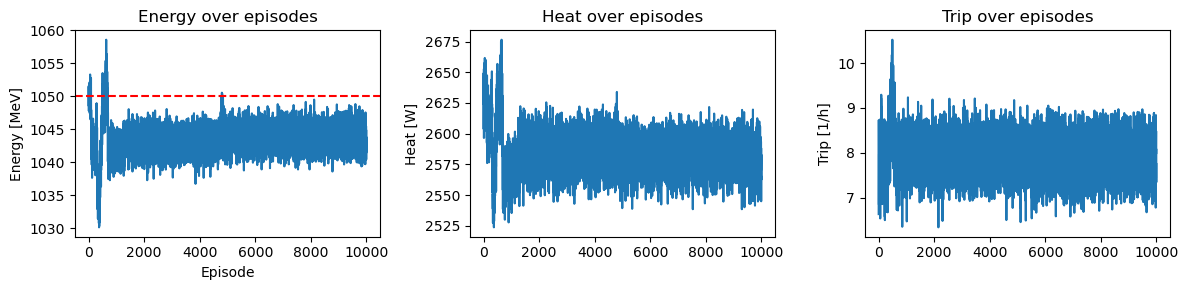

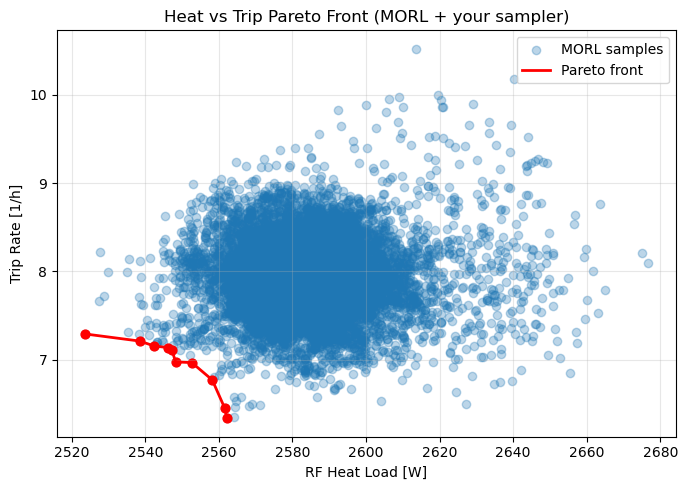

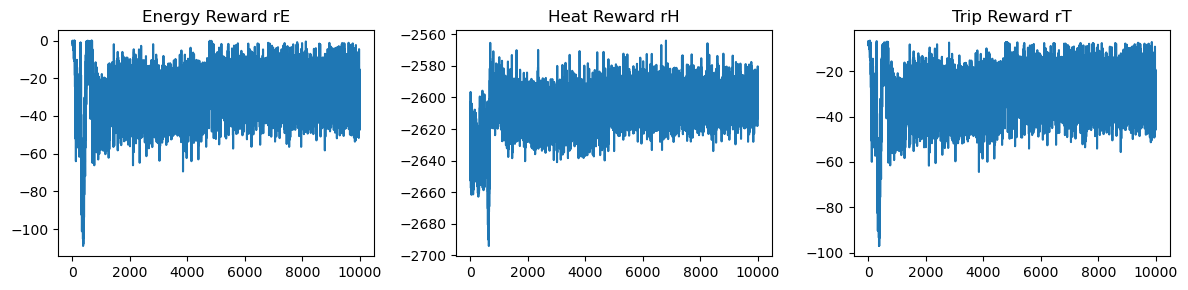

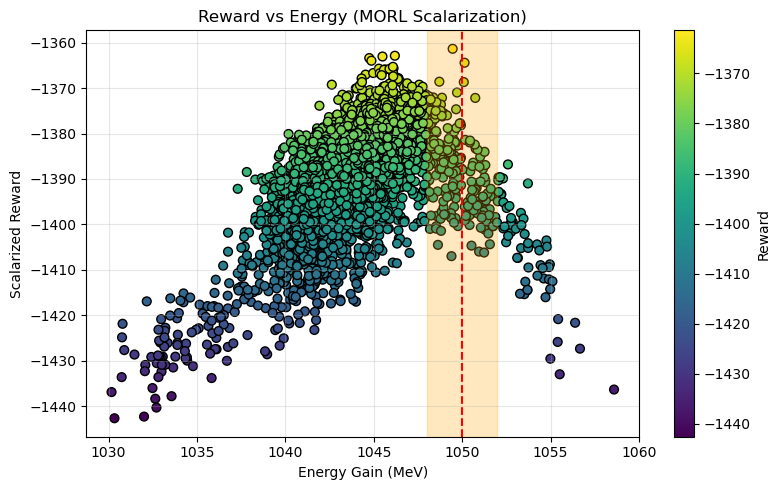

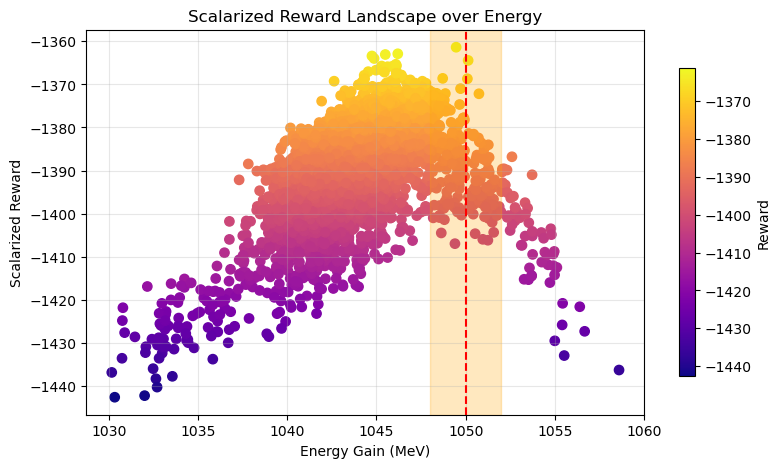


Running traditional random sampling ...


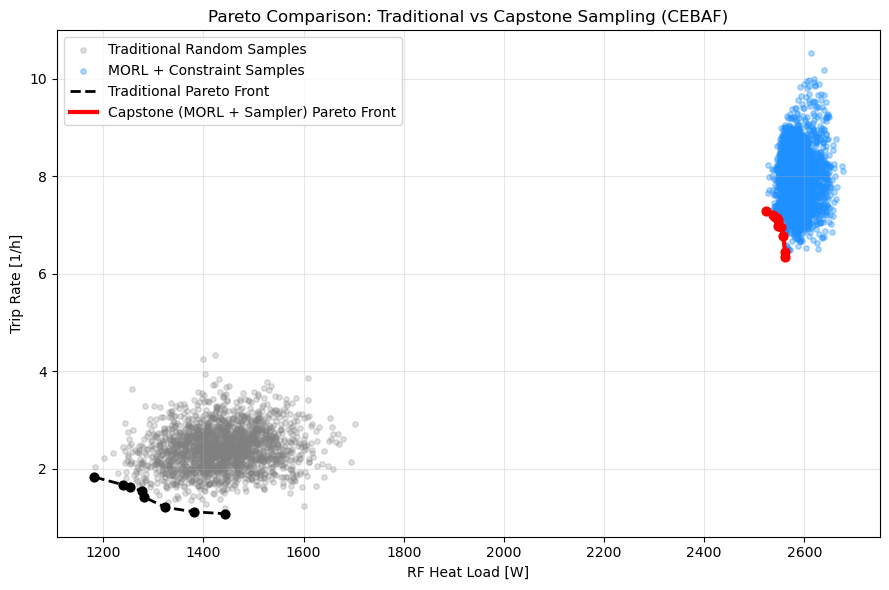

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
train_start = time.time()
time_stamps = []


# ==== PyTorch (GPU-ready) ====
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================================================
# 0. DigitalTwin from SciOptControlToolkit (SOCT)
# ===============================================================
# Assumes you already have the SOCT DigitalTwin class imported / defined.
# Example:
# from SciOptControlToolkit import DigitalTwin

path_cavity_data = "cavity_table.pkl"
twin = DigitalTwin(path_cavity_data, linac="North", implementation="np")

# Convenience: inspect energy target & bounds
E_target = twin.get_energy_mean()
E_margin = twin.get_energy_margin()
E_low, E_high = E_target - E_margin, E_target + E_margin
print(f"Required energy mean: {E_target:.1f} ± {E_margin:.1f}  "
      f"(band = [{E_low:.1f}, {E_high:.1f}])")


# ===============================================================
# 1. YOUR CONSTRAINT-AWARE SAMPLER (unchanged logic)
# ===============================================================
def iterative_constraint_sampler(twin, num_samples=3000, max_iter=5):
    """
    Your original constraint-aware sampler:
    - random uniform start in [min_g, max_g]
    - iteratively pushes energy into [target ± margin]
    - returns only valid samples, but we also keep *all* energies for analysis
    """
    min_g = twin.getMinGradients().astype(float)
    max_g = twin.getMaxGradients().astype(float)
    lengths = twin.lengths.astype(float)

    target = twin.get_energy_mean()
    margin = twin.get_energy_margin()
    lower, upper = target - margin, target + margin

    valid_samples, valid_energies = [], []
    all_energies = []

    for _ in range(num_samples):
        g = np.random.uniform(min_g, max_g)
        E = np.sum(g * lengths)
        all_energies.append(E)

        for _ in range(max_iter):
            if E < lower:
                g += 0.5 * (max_g - g)          # push up
            elif E > upper:
                g -= 0.5 * (g - min_g)          # push down
            else:
                break
            g = np.clip(g, min_g, max_g)
            E = np.sum(g * lengths)

        if lower <= E <= upper:
            valid_samples.append(g.copy())
            valid_energies.append(E)

    valid_samples   = np.array(valid_samples)
    valid_energies  = np.array(valid_energies)
    all_energies    = np.array(all_energies)
    eff = 100.0 * len(valid_samples) / num_samples

    print(f"\nTarget energy band: [{lower:.2f}, {upper:.2f}]")
    print(f"Total draws: {num_samples} | Valid inside band: {len(valid_samples)} "
          f"({eff:.2f}%)")

    return valid_samples, valid_energies, all_energies, eff


valid_samples, valid_energies, all_energies, eff = iterative_constraint_sampler(
    twin, num_samples=3000
)


# ===============================================================
# 2. HELPER: compute energy, heat, trip from gradients via SOCT
# ===============================================================
def get_metrics_from_gradients(twin, g):
    twin.setGradients(g, mode="direct")
    E = float(twin.getEnergyGain())
    H = float(twin.getRFHeat())
    T = float(twin.getTripRates())
    return E, H, T


# ===============================================================
# 3. MORL ENVIRONMENT (uses your sampler as initial pool)
# ===============================================================
class CavityEnvMORL:
    """
    Multi-objective environment for CEBAF:
      - state  = normalized gradient vector
      - action = delta in normalized space in [-1,1]
      - reward = 3D vector [r_E, r_H, r_T] (no weighted sum)
    """

    def __init__(self, twin, init_pool=None, action_scale=0.1):
        self.twin = twin
        self.min_g = twin.getMinGradients().astype(np.float32)
        self.max_g = twin.getMaxGradients().astype(np.float32)
        self.target = twin.get_energy_mean()
        self.margin = twin.get_energy_margin()
        self.action_scale = action_scale

        self.n_cav = len(self.min_g)
        self.init_pool = init_pool  # your sampler outputs

    def _normalize(self, g):
        return (g - self.min_g) / (self.max_g - self.min_g + 1e-8)

    def reset(self):
        # Start from one of your sampler's valid points (if available)
        if self.init_pool is not None and len(self.init_pool) > 0:
            idx = np.random.randint(len(self.init_pool))
            self.g = self.init_pool[idx].astype(np.float32).copy()
        else:
            self.g = np.random.uniform(self.min_g, self.max_g).astype(np.float32)
        return self._normalize(self.g)

    def step(self, action):
        action = np.clip(action, -1.0, 1.0).astype(np.float32)
        delta_g = action * (self.max_g - self.min_g) * self.action_scale
        self.g = np.clip(self.g + delta_g, self.min_g, self.max_g)

        # physics from SOCT
        E, H, T = get_metrics_from_gradients(self.twin, self.g)

        # --- multi-objective reward vector ---
        # (1) energy objective: closer to target is better,
        #     plus extra penalty if outside the allowed band
        if E < self.target - self.margin:
            penalty = -5.0 * abs(E - (self.target - self.margin))
        elif E > self.target + self.margin:
            penalty = -5.0 * abs(E - (self.target + self.margin))
        else:
            penalty = 0.0

        r_E = -abs(E - self.target) + penalty  # maximize closeness to target
        r_H = -H + penalty                      # minimize heat
        r_T = -T + penalty                      # minimize trip rate

        reward_vec = np.array([r_E, r_H, r_T], dtype=np.float32)

        next_state = self._normalize(self.g)
        done = True   # 1-step bandit episode
        info = {"energy": E, "heat": H, "trip": T, "reward_vec": reward_vec}
        return next_state, reward_vec, done, info


env = CavityEnvMORL(twin, init_pool=valid_samples, action_scale=0.1)


# ===============================================================
# 4. MOTD3-STYLE MULTI-OBJECTIVE AGENT (PyTorch)
# ===============================================================
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim), nn.Tanh()  # outputs in [-1,1]
        )

    def forward(self, x):
        return self.net(x)


class Critic(nn.Module):
    """
    Multi-objective critic: Q(s,a) -> R^3 (energy, heat, trip objectives)
    """
    def __init__(self, state_dim, action_dim, n_obj=3, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_obj)
        )

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        return self.net(x)  # [B, n_obj]


class ReplayBuffer:
    def __init__(self, max_size=100000):
        self.max = max_size
        self.size = 0
        self.ptr = 0
        self.s = []
        self.a = []
        self.r = []

    def add(self, s, a, r_vec):
        if self.size < self.max:
            self.s.append(s)
            self.a.append(a)
            self.r.append(r_vec)
            self.size += 1
        else:
            i = self.ptr
            self.s[i] = s
            self.a[i] = a
            self.r[i] = r_vec
            self.ptr = (self.ptr + 1) % self.max

    def sample(self, batch):
        idx = np.random.randint(0, self.size, batch)
        s = np.array([self.s[i] for i in idx], dtype=np.float32)
        a = np.array([self.a[i] for i in idx], dtype=np.float32)
        r = np.array([self.r[i] for i in idx], dtype=np.float32)
        return s, a, r


class MOTD3Agent:
    """
    Minimal MOTD3:
    - Critic outputs 3 objectives
    - Training target for each objective is just the immediate reward vector
      (bandit), no bootstrapping across time.
    - Policy is updated by sampling a random preference vector w on the simplex
      and maximizing w·Q(s,a).
    """

    def __init__(self, state_dim, action_dim, n_obj=3,
                 actor_lr=1e-3, critic_lr=1e-3,
                 tau=0.005, device=device):
        self.device = device
        self.n_obj = n_obj

        self.actor = Actor(state_dim, action_dim).to(device)
        self.actor_t = Actor(state_dim, action_dim).to(device)
        self.actor_t.load_state_dict(self.actor.state_dict())

        self.critic1 = Critic(state_dim, action_dim, n_obj=n_obj).to(device)
        self.critic2 = Critic(state_dim, action_dim, n_obj=n_obj).to(device)
        self.critic1_t = Critic(state_dim, action_dim, n_obj=n_obj).to(device)
        self.critic2_t = Critic(state_dim, action_dim, n_obj=n_obj).to(device)
        self.critic1_t.load_state_dict(self.critic1.state_dict())
        self.critic2_t.load_state_dict(self.critic2.state_dict())

        self.optA = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.optC = optim.Adam(
            list(self.critic1.parameters()) + list(self.critic2.parameters()),
            lr=critic_lr
        )

        self.tau = tau
        self.total_it = 0

    def select_action(self, s, noise=0.1):
        s_t = torch.tensor(s, device=self.device).float().unsqueeze(0)
        with torch.no_grad():
            a = self.actor(s_t).cpu().numpy()[0]
        if noise > 0:
            a = a + noise * np.random.randn(*a.shape)
        return np.clip(a, -1.0, 1.0)

    def train_step(self, rb, batch=64, policy_delay=2):
        if rb.size < batch:
            return

        self.total_it += 1

        s, a, r = rb.sample(batch)
        s = torch.tensor(s, device=self.device).float()
        a = torch.tensor(a, device=self.device).float()
        r = torch.tensor(r, device=self.device).float()  # [B, 3]

        # bandit: target Q = immediate reward vector
        target_q = r

        q1 = self.critic1(s, a)
        q2 = self.critic2(s, a)

        lossC = nn.MSELoss()(q1, target_q) + nn.MSELoss()(q2, target_q)
        self.optC.zero_grad()
        lossC.backward()
        self.optC.step()

        # delayed policy update (TD3)
        if self.total_it % policy_delay == 0:
            # Sample random preference vector on simplex
            w = np.random.rand(self.n_obj)
            w /= (w.sum() + 1e-8)
            w_t = torch.tensor(w, device=self.device).float().view(1, -1)

            a_pi = self.actor(s)
            q1_pi = self.critic1(s, a_pi)                    # [B,3]
            scalarized = (q1_pi * w_t).sum(dim=1).mean()     # scalar

            lossA = -scalarized
            self.optA.zero_grad()
            lossA.backward()
            self.optA.step()

            # soft update targets
            for net, tgt in [(self.actor, self.actor_t),
                             (self.critic1, self.critic1_t),
                             (self.critic2, self.critic2_t)]:
                for p, tp in zip(net.parameters(), tgt.parameters()):
                    tp.data.copy_(self.tau * p.data + (1 - self.tau) * tp.data)


# ===============================================================
# 5. TRAINING LOOP (MORL + YOUR SAMPLER)
# ===============================================================
state_dim = env.n_cav
action_dim = env.n_cav

agent = MOTD3Agent(state_dim, action_dim, n_obj=3, device=device)
buffer = ReplayBuffer(max_size=50000)

episodes = 10000
history_E, history_H, history_T = [], [], []

for ep in range(episodes):
    s = env.reset()
    a = agent.select_action(s, noise=0.15)
    s2, r_vec, done, info = env.step(a)

    buffer.add(s, a, r_vec)
    agent.train_step(buffer, batch=64)

    history_E.append(info["energy"])
    history_H.append(info["heat"])
    history_T.append(info["trip"])

    time_stamps.append(time.time() - train_start)
    if (ep + 1) % 100 == 0:
        print(f"Ep {ep+1}/{episodes} | "
              f"E={info['energy']:.2f} MeV  "
              f"H={info['heat']:.1f} W  "
              f"T={info['trip']:.3f} 1/h")


# ===============================================================
# 6. PLOTS: LEARNING + PARETO FRONT
# ===============================================================
history_E = np.array(history_E)
history_H = np.array(history_H)
history_T = np.array(history_T)

# --- Learning curves ---
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
plt.plot(history_E); plt.axhline(E_target, color='r', linestyle='--')
plt.title("Energy over episodes"); plt.ylabel("Energy [MeV]"); plt.xlabel("Episode")

plt.subplot(1,3,2)
plt.plot(history_H); plt.title("Heat over episodes"); plt.ylabel("Heat [W]")

plt.subplot(1,3,3)
plt.plot(history_T); plt.title("Trip over episodes"); plt.ylabel("Trip [1/h]")
plt.tight_layout()
plt.show()

# --- Pareto front Heat vs Trip ---
points = np.vstack([history_H, history_T]).T
is_pareto = np.ones(points.shape[0], dtype=bool)
for i, p in enumerate(points):
    if is_pareto[i]:
        is_pareto[is_pareto] = (
            (points[is_pareto][:,0] < p[0]) |
            (points[is_pareto][:,1] < p[1]) |
            np.all(points[is_pareto] == p, axis=1)
        )
        is_pareto[i] = True

pf = points[is_pareto]
pf = pf[np.argsort(pf[:,0])]

plt.figure(figsize=(7,5))
plt.scatter(points[:,0], points[:,1], alpha=0.3, label="MORL samples")
plt.plot(pf[:,0], pf[:,1], 'r-', lw=2, label="Pareto front")
plt.scatter(pf[:,0], pf[:,1], c='r', s=40)
plt.xlabel("RF Heat Load [W]")
plt.ylabel("Trip Rate [1/h]")
plt.title("Heat vs Trip Pareto Front (MORL + your sampler)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
# 7. REWARD VISUALIZATION FOR MORL (3 WAYS)
# ===============================================================

# Convert stored reward vectors
# You already stored r_vec in the buffer, and info in the environment
# but to make plotting easy, re-create them from the history:
R_energy = []
R_heat   = []
R_trip   = []

# re-evaluate rewards for each stored gradient (for plotting)
for i in range(len(history_E)):
    E = history_E[i]
    H = history_H[i]
    T = history_T[i]

    # compute same rewards used in environment:
    if E < E_low:
        penalty = -5 * abs(E - E_low)
    elif E > E_high:
        penalty = -5 * abs(E - E_high)
    else:
        penalty = 0.0

    rE = -abs(E - E_target) + penalty
    rH = -H + penalty
    rT = -T + penalty

    R_energy.append(rE)
    R_heat.append(rH)
    R_trip.append(rT)

R_energy = np.array(R_energy)
R_heat   = np.array(R_heat)
R_trip   = np.array(R_trip)


# ---------------------------------------------------------------
# (A) Per-objective rewards over episodes
# ---------------------------------------------------------------
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
plt.plot(R_energy); plt.title("Energy Reward rE")

plt.subplot(1,3,2)
plt.plot(R_heat);   plt.title("Heat Reward rH")

plt.subplot(1,3,3)
plt.plot(R_trip);   plt.title("Trip Reward rT")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# (B) Scalarized reward vs Energy (like MOTD3 paper)
# ---------------------------------------------------------------
w = np.random.rand(3)
w = w / w.sum()

R_scalar = w[0]*R_energy + w[1]*R_heat + w[2]*R_trip

plt.figure(figsize=(8,5))
plt.scatter(history_E, R_scalar, c=R_scalar,
            cmap='viridis', s=40, edgecolor='k')

plt.axvline(E_target, color='red', linestyle='--')
plt.axvspan(E_low, E_high, color='orange', alpha=0.25)

plt.xlabel("Energy Gain (MeV)")
plt.ylabel("Scalarized Reward")
plt.title("Reward vs Energy (MORL Scalarization)")
plt.colorbar(label="Reward")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# (C) Reward heatmap-style scatter (like your paper figure)
# ---------------------------------------------------------------
plt.figure(figsize=(9,5))
plt.scatter(history_E, R_scalar, c=R_scalar,
            cmap='plasma', s=45)

plt.colorbar(label="Reward", shrink=0.8)
plt.axvline(E_target, color='red', linestyle='--')
plt.axvspan(E_low, E_high, color='orange', alpha=0.25)

plt.xlabel("Energy Gain (MeV)")
plt.ylabel("Scalarized Reward")
plt.title("Scalarized Reward Landscape over Energy")
plt.grid(alpha=0.3)
plt.show()

# ===============================================================
# 8. TRADITIONAL SAMPLING vs YOUR SAMPLING (PARETO COMPARISON)
# ===============================================================

N_TRADITIONAL = 2000

min_g = twin.getMinGradients()
max_g = twin.getMaxGradients()

trad_heat = []
trad_trip = []
trad_energy = []

print("\nRunning traditional random sampling ...")

for i in range(N_TRADITIONAL):
    g = np.random.uniform(min_g, max_g)

    twin.setGradients(g, mode="direct")

    E = float(twin.getEnergyGain())
    H = float(twin.getRFHeat())
    T = float(twin.getTripRates())

    trad_energy.append(E)
    trad_heat.append(H)
    trad_trip.append(T)

trad_heat = np.array(trad_heat)
trad_trip = np.array(trad_trip)


# ------------------------------------------------
# Pareto function
# ------------------------------------------------
def pareto_front(x, y):
    pts = np.vstack([x, y]).T
    is_pareto = np.ones(len(pts), dtype=bool)

    for i, p in enumerate(pts):
        if is_pareto[i]:
            is_pareto[is_pareto] = (
                (pts[is_pareto][:,0] < p[0]) |
                (pts[is_pareto][:,1] < p[1]) |
                np.all(pts[is_pareto] == p, axis=1)
            )
            is_pareto[i] = True

    return pts[is_pareto]


# ------------------------------------------------
# Compute Pareto fronts
# ------------------------------------------------

# Traditional sampling Pareto
pf_traditional = pareto_front(trad_heat, trad_trip)
pf_traditional = pf_traditional[np.argsort(pf_traditional[:,0])]

# Your MORL + sampler Pareto
pf_capstone = pareto_front(history_H, history_T)
pf_capstone = pf_capstone[np.argsort(pf_capstone[:,0])]


# ------------------------------------------------
# FINAL COMPARISON PLOT
# ------------------------------------------------

plt.figure(figsize=(9,6))

# All random points
plt.scatter(trad_heat, trad_trip,
            color="gray", alpha=0.25, s=15,
            label="Traditional Random Samples")

# All MORL + sampler points
plt.scatter(history_H, history_T,
            color="dodgerblue", alpha=0.35, s=15,
            label="MORL + Constraint Samples")

# Pareto fronts
plt.plot(pf_traditional[:,0], pf_traditional[:,1],
         color="black", linestyle="--", linewidth=2,
         label="Traditional Pareto Front")

plt.plot(pf_capstone[:,0], pf_capstone[:,1],
         color="red", linewidth=3,
         label="Capstone (MORL + Sampler) Pareto Front")

plt.scatter(pf_traditional[:,0], pf_traditional[:,1],
            c="black", s=40)

plt.scatter(pf_capstone[:,0], pf_capstone[:,1],
            c="red", s=40)

plt.xlabel("RF Heat Load [W]")
plt.ylabel("Trip Rate [1/h]")
plt.title("Pareto Comparison: Traditional vs Capstone Sampling (CEBAF)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

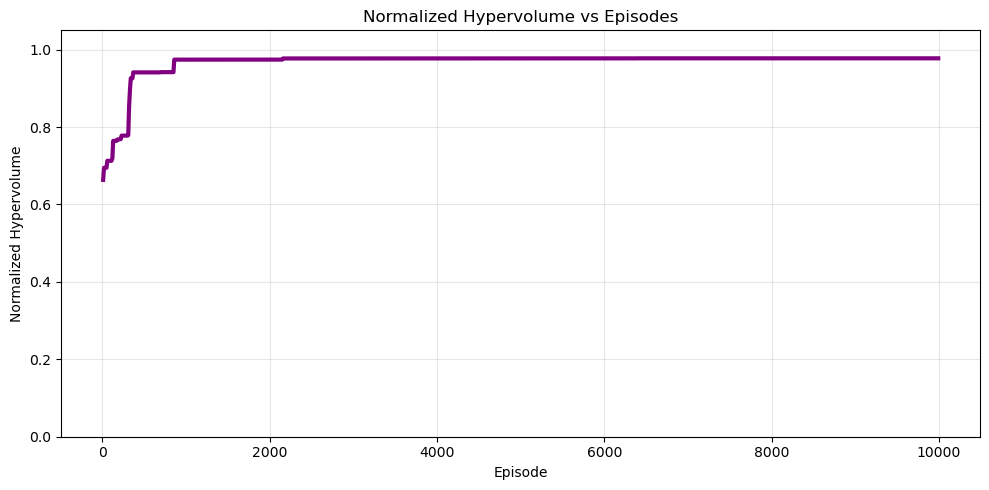

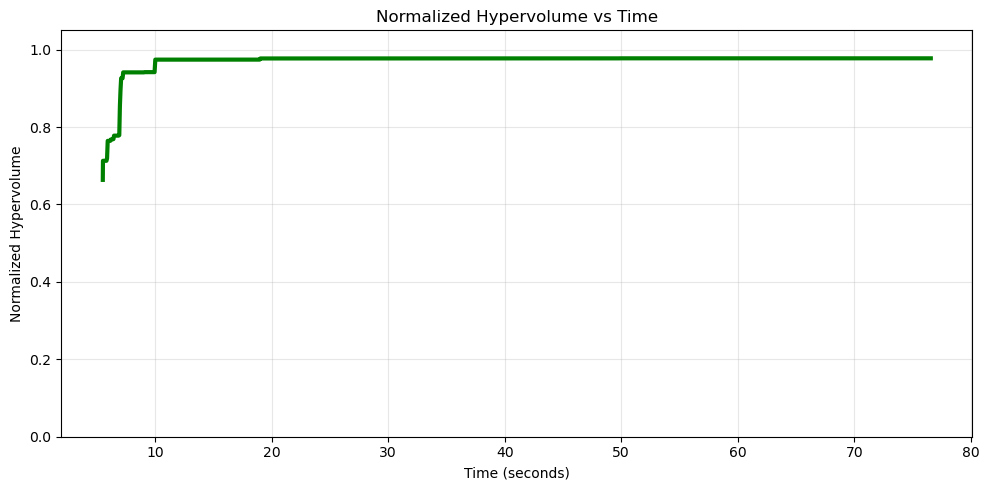

In [4]:
from pymoo.indicators.hv import HV

ideal_heat = np.min(history_H)
ideal_trip = np.min(history_T)
ideal_point = np.array([ideal_heat, ideal_trip])

ref_heat = np.max(history_H) * 1.05
ref_trip = np.max(history_T) * 1.05
ref_point = np.array([ref_heat, ref_trip])

hv_total = HV(ref_point=ref_point)(np.array([ideal_point]))

hv_history = []
episode_markers = []

for k in range(10, len(history_H), 10):
    pareto = pareto_front(history_H[:k], history_T[:k])
    hv_val = HV(ref_point=ref_point)(pareto)
    hv_norm = hv_val / hv_total

    hv_history.append(hv_norm)
    episode_markers.append(k)

hv_time = [time_stamps[k-1] for k in episode_markers]

plt.figure(figsize=(10,5))
plt.plot(episode_markers, hv_history, lw=3, color="purple")
plt.xlabel("Episode")
plt.ylabel("Normalized Hypervolume")
plt.title("Normalized Hypervolume vs Episodes")
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(hv_time, hv_history, lw=3, color="green")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Hypervolume")
plt.title("Normalized Hypervolume vs Time")
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


Running FAIR comparison (energy-constrained)…
Traditional valid (inside energy band): 0 / 4000


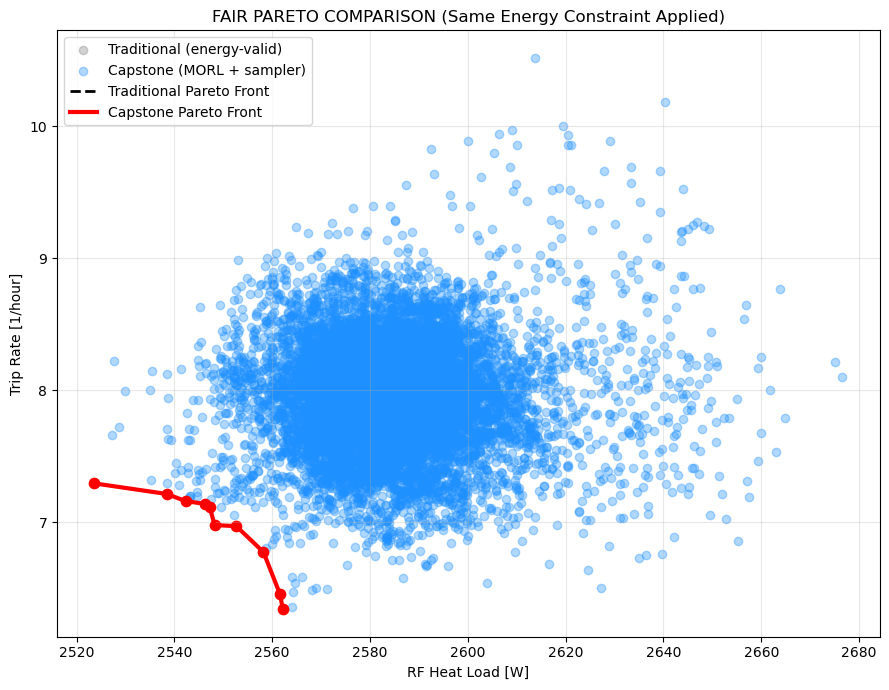

In [6]:
print("\nRunning FAIR comparison (energy-constrained)…")

def traditional_random_sampling(twin, num_samples=4000):
    min_g = twin.getMinGradients()
    max_g = twin.getMaxGradients()

    E_all, H_all, T_all = [], [], []
    E_valid_trad, H_valid_trad, T_valid_trad = [], [], []

    for _ in range(num_samples):
        g = np.random.uniform(min_g, max_g)
        E, H, T = get_metrics_from_gradients(twin, g)

        E_all.append(E); H_all.append(H); T_all.append(T)

        if E_low <= E <= E_high:
            E_valid_trad.append(E)
            H_valid_trad.append(H)
            T_valid_trad.append(T)

    print(f"Traditional valid (inside energy band): {len(E_valid_trad)} / {num_samples}")

    return (
        np.array(E_all), np.array(H_all), np.array(T_all),
        np.array(E_valid_trad), np.array(H_valid_trad), np.array(T_valid_trad)
    )


E_all_trad, H_all_trad, T_all_trad, \
E_valid_trad, H_valid_trad, T_valid_trad = traditional_random_sampling(twin, num_samples=4000)

def get_pareto_front(x, y):
    points = np.vstack([x, y]).T
    is_pareto = np.ones(points.shape[0], dtype=bool)

    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = (
                (points[is_pareto][:, 0] < p[0]) |
                (points[is_pareto][:, 1] < p[1]) |
                np.all(points[is_pareto] == p, axis=1)
            )
            is_pareto[i] = True

    pareto = points[is_pareto]
    pareto = pareto[np.argsort(pareto[:,0])]
    return pareto

pareto_trad = get_pareto_front(H_valid_trad, T_valid_trad)

pareto_capstone = get_pareto_front(history_H, history_T)

plt.figure(figsize=(9,7))

plt.scatter(H_valid_trad, T_valid_trad,
            color='gray', alpha=0.35, label="Traditional (energy-valid)")

plt.scatter(history_H, history_T,
            color='dodgerblue', alpha=0.35, label="Capstone (MORL + sampler)")

plt.plot(pareto_trad[:,0], pareto_trad[:,1],
         'k--', lw=2, label="Traditional Pareto Front")

plt.plot(pareto_capstone[:,0], pareto_capstone[:,1],
         'r-', lw=3, label="Capstone Pareto Front")

plt.scatter(pareto_trad[:,0], pareto_trad[:,1], color='black', s=45)
plt.scatter(pareto_capstone[:,0], pareto_capstone[:,1], color='red', s=55)

plt.xlabel("RF Heat Load [W]")
plt.ylabel("Trip Rate [1/hour]")
plt.title("FAIR PARETO COMPARISON (Same Energy Constraint Applied)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()